In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import matplotlib.pyplot as plt

In [5]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

In [6]:
from PIL import Image
from torch.utils.data import Dataset
import os

class AnimeDataset(Dataset):

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.images = [
            os.path.join(root_dir, img)
            for img in os.listdir(root_dir)
            if img.endswith((".jpg", ".png", ".jpeg"))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = Image.open(
            self.images[idx]
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

In [7]:
dataset_path = "/kaggle/input/datasets/splcher/animefacedataset/images"

dataset = AnimeDataset(
    dataset_path,
    transform
)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

print(len(dataset))

63565


In [8]:
latent_dim = 100

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(

            nn.ConvTranspose2d(
                latent_dim,
                512,
                4,
                1,
                0,
                bias=False
            ),

            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                512,
                256,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                256,
                128,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                128,
                64,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                64,
                3,
                4,
                2,
                1,
                bias=False
            ),

            nn.Tanh()
        )

    def forward(self,x):
        return self.main(x)

In [9]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(

            nn.Conv2d(
                3,
                64,
                4,
                2,
                1,
                bias=False
            ),

            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                64,
                128,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(128),

            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                128,
                256,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(256),

            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                256,
                512,
                4,
                2,
                1,
                bias=False
            ),

            nn.BatchNorm2d(512),

            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                512,
                1,
                4,
                1,
                0,
                bias=False
            ),

            nn.Sigmoid()
        )

    def forward(self,x):
        return self.main(x).view(-1,1)

In [10]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

G = Generator().to(device)

noise = torch.randn(
    4,
    latent_dim,
    1,
    1
).to(device)

fake = G(noise)

print(fake.shape)

torch.Size([4, 3, 64, 64])


In [11]:
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    G.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    D.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

In [12]:
epochs = 5

for epoch in range(epochs):

    for real_imgs in loader:

        real_imgs = real_imgs.to(device)

        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Train Discriminator

        optimizer_D.zero_grad()

        real_output = D(real_imgs)

        d_real_loss = criterion(
            real_output,
            real_labels
        )

        noise = torch.randn(
            batch_size,
            latent_dim,
            1,
            1
        ).to(device)

        fake_imgs = G(noise)

        fake_output = D(
            fake_imgs.detach()
        )

        d_fake_loss = criterion(
            fake_output,
            fake_labels
        )

        d_loss = d_real_loss + d_fake_loss

        d_loss.backward()

        optimizer_D.step()

        # Train Generator

        optimizer_G.zero_grad()

        noise = torch.randn(
            batch_size,
            latent_dim,
            1,
            1
        ).to(device)

        fake_imgs = G(noise)

        output = D(fake_imgs)

        g_loss = criterion(
            output,
            real_labels
        )

        g_loss.backward()

        optimizer_G.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

Epoch [1/5] D Loss: 0.2973 G Loss: 5.0763
Epoch [2/5] D Loss: 0.0449 G Loss: 3.2982
Epoch [3/5] D Loss: 0.2129 G Loss: 4.8260
Epoch [4/5] D Loss: 0.0082 G Loss: 9.6961
Epoch [5/5] D Loss: 0.0299 G Loss: 5.5962


In [14]:
noise = torch.randn(
    16,
    latent_dim,
    1,
    1
).to(device)

with torch.no_grad():
    generated = G(noise).cpu()

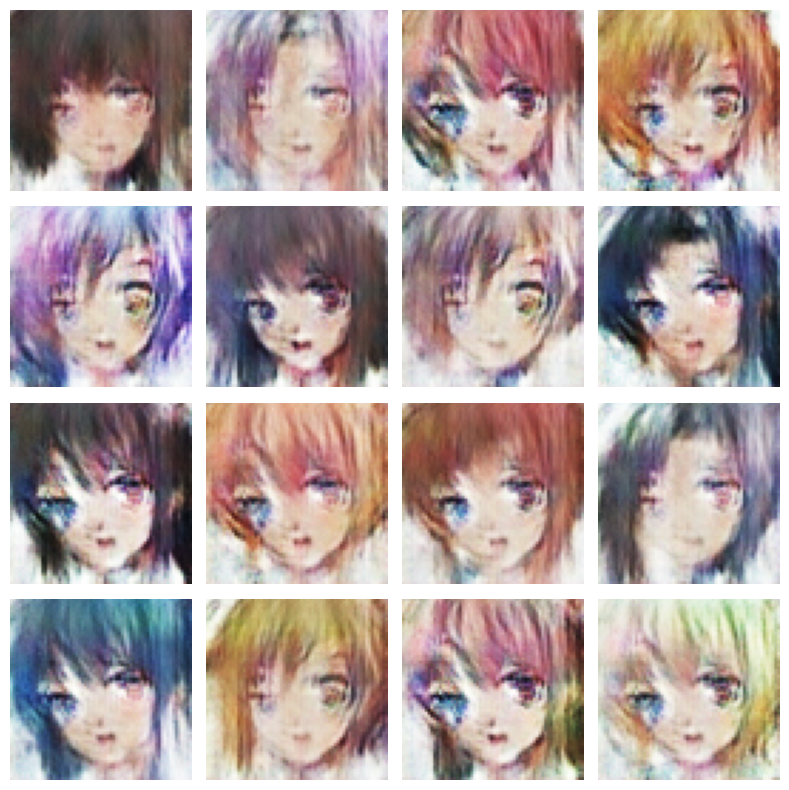

In [15]:
fig, axes = plt.subplots(4,4,figsize=(8,8))

for i, ax in enumerate(axes.flatten()):

    img = generated[i]

    img = img.permute(1,2,0)

    img = (img + 1) / 2

    img = img.clamp(0,1)

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()